# Introduction

This project builds a stock price prediction model using XGBoost, a powerful gradient 
boosting framework. The model is trained on historical closing prices with feature
engineering that includes lag values and moving averages.

It is designed to evaluate how well a tree-based ensemble method can learn pricing
patterns from a single stock and make accurate predictions on others. The script
outputs RMSE scores and generates plots comparing actual vs. predicted prices.

Purpose:
- Leverage XGBoost’s ability to model non-linear relationships in financial time series.
- Assess its predictive performance across a diverse set of tech sector stocks.


## Importing Dependencies

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt


## Experimenting with 'AAPL' stock

### Importing AAPL stock and converting it to a numpy array

In [29]:

# Step 1: Fetch the data and convert to NumPy array
ticker = "AAPL"
data = yf.download(ticker, start="2014-12-01", end="2024-12-01")
data = data[['Close']].to_numpy()  # Use only the closing price and convert to NumPy array
data
data.shape

[*********************100%***********************]  1 of 1 completed


(2517, 1)

### Creating features for inputs (lag days, moving averages)

In [35]:

# Step 2: Create features
def create_features(data, lag_days=60):
    """
    Add lagged features and moving averages to the NumPy array.
    """
    rows, _ = data.shape
    features = []
    for i in range(lag_days, rows):
        # Create lagged features and moving averages
        lagged = data[i-lag_days:i].flatten()  # Lagged features
#         ma_7 = data[i-7:i].mean() if i >= 7 else np.nan  # 7-day moving average
#         ma_30 = data[i-30:i].mean() if i >= 30 else np.nan  # 30-day moving average
#         features.append(np.concatenate([lagged, [ma_7, ma_30, data[i][0]]]))
        features.append(np.concatenate([lagged, [data[i][0]]]))
    features = np.array(features)
    return features[~np.isnan(features).any(axis=1)]  # Remove rows with NaN values

features = create_features(data)
X = features[:, :-1]  # All columns except the last (which is the target)
y = features[:, -1]   # Last column is the target (current closing price)

X.shape, X[:5,:], y[:5]

((2457, 60),
 array([[25.62543869, 25.52745247, 25.81695938, 25.71896172, 25.60985184,
         25.03084183, 25.41387939, 24.93063164, 24.85714912, 24.43624878,
         24.10220909, 23.77261734, 24.36498642, 25.08652115, 24.89277077,
         25.15110016, 25.06201935, 24.94399261, 25.38492966, 25.3671093 ,
         25.05755806, 24.58100128, 24.34717369, 23.66127396, 23.66350555,
         23.99531174, 24.91727448, 24.94399261, 24.32935143, 24.5453701 ,
         24.45183754, 23.78820229, 23.60337067, 24.2113266 , 24.39616585,
         25.03084183, 25.16000557, 25.18672943, 24.30485725, 25.67888641,
         26.4783535 , 26.090868  , 26.41822624, 26.42268372, 26.62533379,
         26.81537056, 26.58956146, 26.76618767, 27.28040123, 27.91982079,
         28.27307129, 28.41168213, 28.57936478, 28.77834511, 28.71797562,
         28.95273018, 29.73524284, 29.54966545, 28.79400063, 29.15841866],
        [25.52745247, 25.81695938, 25.71896172, 25.60985184, 25.03084183,
         25.41387939, 24

### Standardizing the input data points and splitting of data for training and testing

In [58]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = y

In [59]:
# Step 3: Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, shuffle=False)



### Fitting the data to an XGBoost model

In [141]:
# Step 4: Train the Gradient Boosting model (XGBoost)
# model = XGBRegressor(
#     n_estimators=500,  # Number of trees
#     learning_rate=0.05,  # Step size shrinkage
#     max_depth=6,  # Maximum tree depth
#     subsample=0.9,  # Subsample ratio of the training instance
#     random_state=42  # Random seed
# )
# model.fit(X_train, y_train)

model = XGBRegressor(
    n_estimators=550,           # Number of boosting rounds
    learning_rate=0.08,         # Step size shrinkage
    max_depth=6,                # Maximum depth of each tree
    min_child_weight=5,         # Minimum sum of weights in a leaf
    subsample=0.9,              # Use 80% of samples per tree
    colsample_bytree=0.8,       # Use 80% of features per tree
    gamma=0.1,                  # Minimum loss reduction for splits
    reg_alpha=0.1,              # L1 regularization
    reg_lambda=1.0,             # L2 regularization
    random_state=42,            # Random seed
    eval_metric="rmse",         # Evaluation metric
)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             gamma=0.1, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.08, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=5, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=550, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [18]:
# from sklearn import set_config
# set_config(display="text")  # Force plain text output for model representation


#### Using RMSE value as means to evaluate the performance of the model

In [142]:
# Step 5: Evaluate the model
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.2f}")



RMSE: 27.10


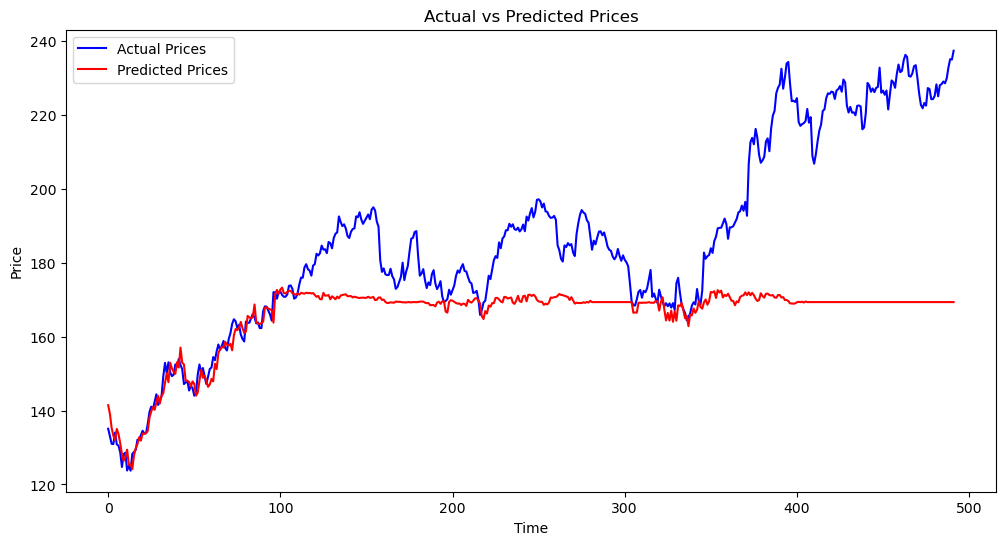

In [62]:
# Plot actual vs predicted prices
plt.figure(figsize=(12, 6))
plt.plot(y_test, label="Actual Prices", color="blue")
plt.plot(y_pred, label="Predicted Prices", color="red")
plt.legend()
plt.title("Actual vs Predicted Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()


### Conclusion

This project explored the application of XGBoost for stock price prediction using features such as lagged closing prices and moving averages. While the results presented focus specifically on AAPL stock, extensive experimentation was conducted across multiple model configurations and tech stocks, including GOOG, MSFT, and NVDA.

Despite attempts to tune hyperparameters and vary feature engineering strategies, the model did not produce consistently reliable predictions across different stocks. This suggests that tree-based models like XGBoost may struggle with the highly volatile and non-stationary nature of financial time series data.

The findings indicate that while XGBoost can capture patterns in specific stocks under stable conditions, its generalization capability remains limited. Incorporating additional contextual features such as trading volume, news sentiment, or macroeconomic indicators or combining XGBoost with deep learning architectures may offer more robust predictive performance in future studies.
